# **1. Alien vs Predator 데이터셋**
Alien vs Predator 데이터셋은 컴퓨터 비전과 이미지 분류 모델을 학습시키기 위해 제공되는 소규모 데이터셋입니다. 이 데이터셋은 영화 속 캐릭터인 에일리언(Alien)과 프레데터(Predator)의 이미지로 구성되어 있습니다. 이 데이터를 통해 이 두 클래스를 분류하는 이미지 분류 모델을 학습시킬 수 있습니다.

In [1]:
from pathlib import Path

In [2]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data' / 'alien_vs_predator'
print(f'프로젝트 폴더: {PROJECT_DIR}')
print(f'데이터 폴더: {DATA_DIR}')

프로젝트 폴더: c:\Ryuzy\3_MLDL
데이터 폴더: c:\Ryuzy\3_MLDL\data\alien_vs_predator


In [3]:
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'validation'
print(f'학습용 폴더: {TRAIN_DIR}')
print(f'검증용 폴더: {VAL_DIR}')

학습용 폴더: c:\Ryuzy\3_MLDL\data\alien_vs_predator\train
검증용 폴더: c:\Ryuzy\3_MLDL\data\alien_vs_predator\validation


# **2. Alexnet 모델을 활용한 Alien vs Predator 분류**

### ※ 이미지넷
이미지넷(ImageNet)은 대규모 이미지 데이터셋으로, 컴퓨터 비전 연구와 딥러닝 모델 학습에 널리 사용됩니다. 2009년 스탠포드 대학의 페이페이 리(Fei-Fei Li) 교수팀이 구축했으며, 약 1,400만 장의 이미지와 22,000개 이상의 카테고리로 구성되어 있습니다. 이 중, 가장 널리 사용되는 ILSVRC(Imagenet Large Scale Visual Recognition Challenge) 버전은 약 1,000개의 클래스와 120만 장의 이미지를 포함합니다. 이미지넷은 모델이 객체를 분류하고 특징을 학습하는 데 필요한 풍부한 데이터와 레이블을 제공하며, ResNet, VGG, Inception 등 여러 혁신적인 모델이 이미지넷 대회를 통해 개발되었습니다. 이 데이터셋은 특히 사전 학습(Transfer Learning)에서 중요한 역할을 하며, 딥러닝 연구의 표준 벤치마크로 자리 잡았습니다.

In [4]:
IMAGE_SIZE = 224

# AlexNet IMAGENET1K_V1 가중치에 맞는 평균과 표준편차 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.224]

In [5]:
from torchvision import transforms, datasets, models

In [6]:
data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=8, shear=8),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    "validation": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

### 데이터 증강을 과하게 사용하면 안 되는 이유
- 데이터 증강은 학습 이미지의 모양을 조금씩 바꿔 과적합을 줄이는 방법
- 실제 서비스에서 발생하지 않을 정도로 이미지를 심하게 회전하거나 찌그러뜨리면 오히려 잘못된 특징을 학습할 수 있음
- 먼저 원본 데이터의 촬영 방향, 배경, 밝기, 객체 크기를 분석하고 실제 운영 환경에서 발생할 수 있는 변화만 증강에 반영

In [7]:
image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, transform=data_transforms['train']),
    'validation': datasets.ImageFolder(VAL_DIR, transform=data_transforms['validation'])
}

class_names = image_datasets['train'].classes
print(class_names)
class_to_idx = image_datasets['train'].class_to_idx
print(class_to_idx)
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
print(idx_to_class)

print('학습 이미지 수: ', len(image_datasets['train']))
print('검증 이미지 수: ', len(image_datasets['validation']))

['alien', 'predator']
{'alien': 0, 'predator': 1}
{0: 'alien', 1: 'predator'}
학습 이미지 수:  694
검증 이미지 수:  200


### DataLoader 설정
- batch_size: 한 번에 모델에 넣는 이미지 수
- shuffle=True: 학습 데이터 순서를 매 epoch마다 섞음
- 검증 데이터는 순서를 섞을 필요가 없음
- CUDA에서 pin_memory=True를 사용하면 CPU메모리에서 GPU 데이터를 전달할 때 도움이 될 수 있음

> 메모리 부족 오류가 발생할면 가장 먼저 BATCH_SIZE를 32에서 16 또는 8로 낮춤

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [9]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon GPU (MPS)"
else:
    device = torch.device("cpu")
    device_name = "CPU"

In [10]:
device_name

'NVIDIA GeForce RTX 3060'

In [11]:
BATCH_SIZE = 32
NUM_WORKERS = 0 # 
PIN_MEMORY = device.type == 'cuda'

In [12]:
SEED = 2026

In [13]:
# PyTorch의 난수 생성기를 하나 만듦
# 딥러닝에서는 랜덤 요소가 굉장히 많음(가중치 초기값, 데이터 섞기, 데이터 증강, train/val 분리)
# 난수 생성기의 시작값을 고정(재현성)
generator = torch.Generator()
generator.manual_seed(SEED)

In [14]:
# persistent_workers: epoch가 끝나면 worker가 종료됨. worker를 재사용할 수 있도록 함
dataloaders = {
    "train": DataLoader(
        image_datasets['train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        generator=generator,
        persistent_workers=NUM_WORKERS > 0
    ),
    "validation": DataLoader(
        image_datasets['validation'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0
    )
}

In [15]:
images, labels = next(iter(dataloaders['train']))
print('이미지 배치 shape: ', images.shape)
print('레이블 배치 shape: ', labels.shape)
print('레이블 dtype: ', labels.dtype)

이미지 배치 shape:  torch.Size([32, 3, 224, 224])
레이블 배치 shape:  torch.Size([32])
레이블 dtype:  torch.int64


### 정규화된 이미지 시각화
- 정규화된 텐서를 그대로 imshow()에 넣으면 색상이 이상하게 보일 수 있음
- 화면에 표시할 때는 평균과 표준편차를 이용해 정규화를 되돌림

In [16]:
import matplotlib.pyplot as plt

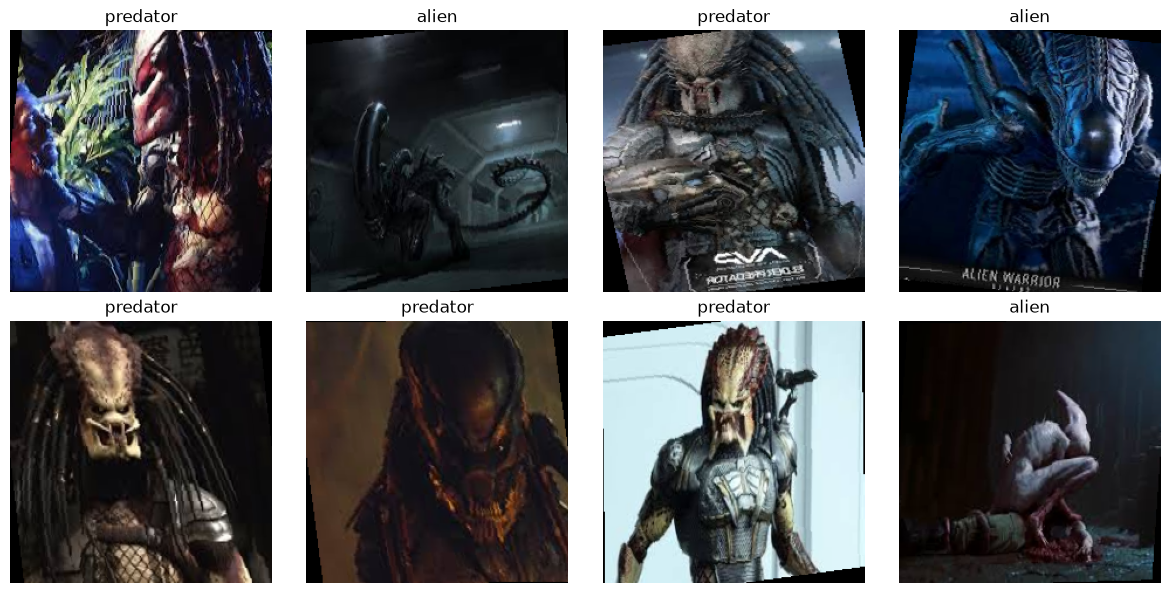

In [17]:
def denormalize_image(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return image.clamp(0, 1)

images, labels = next(iter(dataloaders["train"]))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.flatten(), images[:8], labels[:8]):
    ax.imshow(denormalize_image(image).permute(1, 2, 0))
    ax.set_title(idx_to_class[label.item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

### 전이 학습 모델 만들기
전이 학습(Transfer Learning)은 이미 학습된 모델(주로 대규모 데이터셋에서 사전 학습된 딥러닝 모델)을 새로운 문제에 적용하여 학습 시간을 단축하고 성능을 향상시키는 방법입니다. 기존 모델이 학습한 특징(Feature)을 활용해, 새로운 데이터셋에서 모델의 일부(주로 마지막 레이어)만 다시 학습하거나 추가 학습(Fine-tuning)을 진행합니다. 이는 특히 데이터가 적거나 학습 리소스가 제한된 상황에서 효과적이며, 이미지 분류(예: ResNet, VGG), 자연어 처리(예: BERT, GPT) 등 다양한 분야에서 널리 사용됩니다.

![전이학습](./images/전이학습.png)

In [18]:
from torchvision.models import AlexNet_Weights

In [19]:
weights = AlexNet_Weights.IMAGENET1K_V1
model = models.alexnet(weights=weights)
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### ※ Model Freezing

Model Freezing은 전이 학습(Transfer Learning)에서 사전 학습된 모델의 일부 또는 전체 계층의 가중치를 고정하여 학습되지 않도록 설정하는 기법입니다. 주로 사전 학습된 모델의 초기 계층(Convolutional Layers 등)은 일반적인 특징(예: 가장자리, 패턴)을 학습했으므로 고정하고, 새로운 데이터셋에 특화된 특징을 학습하기 위해 최상위 계층(분류 헤드 등)만 학습합니다. 이 방법은 학습할 가중치의 수를 줄여 계산 비용을 절감하고, 과적합을 방지하며, 데이터가 부족한 상황에서 특히 유용합니다. 필요에 따라, 초기 학습이 끝난 후 일부 계층을 고정 해제(Fine-Tuning)하여 모델을 더 정교하게 조정할 수도 있습니다.

In [20]:
# 사전 학습된 모든 파라미터를 먼저 고정함
for parameter in model.parameters():
    parameter.requires_grad = False

In [21]:
# 마지막 층만 이진 분류용 1개 출력으로 교체함
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, 1)

In [22]:
model = model.to(device)
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [23]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'전체 파라미터 수: {total_params:,}')
print(f'학습 가능한 파라미터 수: {trainable_params:,}')

전체 파라미터 수: 57,007,937
학습 가능한 파라미터 수: 4,097


### BCEWithLogitsLoss
- 이진 분류에서 모델은 확률이 아니라 logit이라는 실수 값을 출력
- 학습 시: BCEWithLogitsLoss(logit, 정답)
- 예측 시: torch.sigmoid(logit)으로 0~1 확률 변환
> Sigmoid와 BCELoss를 따로 적용하는 방식보다 큰 양수나 음수 값에서 추치적으로 더 안정적

In [24]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

print('초기 학습률: ', optimizer.param_groups[0]['lr'])

초기 학습률:  0.001


In [25]:
# NVIDIA CUDA GPU를 쓰고 있으면 AMP를 사용함
# AMP(Automatic Mixed Precision): 자동 혼합 정밀도 연산
# GPU 메모리를 줄이고 학습 속도를 높이는 데 도움이 될 수 있음
# FP32에서는 값을 비교적 잘 표현할 수 있지만, FP16에서는 너무 작아서 0처럼 값이 사라져버릴 수 있음 > underflow
# 이런 현상으로 gradient가 0이 되어버리면 optimizer가 가중치를 제대로 업데이트하지 못함
use_amp = device.type == "cuda"
# GradScaler의 역할: loss를 일시적으로 크게 만들어서 작은 gradient가 사라지는 것을 방지
# 작은 gradient > scale를 곱함 > 큰 gradient > FP16에서도 표현 가능
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

In [26]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_training = optimizer is not None
    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_samples = 0


    # pin_memory=True로 만들어진 DataLoader와 함께 사용할 때 
    # CPU>GPU 복사를 좀 더 효율적으로 할 수 있음
    grad_context = torch.enable_grad() if is_training else torch.inference_mode()
    with grad_context:
        for images, labels in loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.float().unsqueeze(1).to(device, non_blocking=PIN_MEMORY)
            if is_training:
                optimizer.zero_grad()
            with torch.autocast(device_type=device.type,dtype=torch.float16):
                logits = model(images)
                loss = criterion(logits, labels)
            if is_training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (predictions == labels).sum().item()
            running_samples += batch_size

    epoch_loss = running_loss / running_samples
    epoch_accuracy = running_correct / running_samples
    return epoch_loss, epoch_accuracy

### 모델 학습 / 최고 성능 저장 / Early Stopping

In [27]:
EPOCHS = 10
EARLY_STOPPING_PATIENCC = 5
MODEL_PATH = PROJECT_DIR / "best_alien_predator_alexnet.pth"

In [28]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

In [29]:
best_val_loss = float("inf")
epochs_without_improvement = 0

In [30]:
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model=model, loader=dataloaders['train'],
                                      criterion=criterion, device=device, 
                                      optimizer=optimizer)
    val_loss, val_acc = run_epoch(model=model, loader=dataloaders['validation'],
                                      criterion=criterion, device=device, 
                                      optimizer=None)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'Train Loss {train_loss:.4f} | Train Acc {train_acc * 100:.2f}% | '
        f'Val Loss {val_loss:.4f} | Val Acc {val_acc * 100:.2f}% | '
        f'LR {current_lr:.2e}'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_to_idx": class_to_idx,
                "image_size": IMAGE_SIZE,
                "mean": IMAGENET_MEAN,
                "std": IMAGENET_STD,
                "best_val_loss": best_val_loss
            }, MODEL_PATH
        )
        print(f'최고 모델 저장: {MODEL_PATH.name}')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCC:
        print('검증 손실이 개선되지 않아 Early Stopping을 적용합니다.')
        break


Epoch 01/10 | Train Loss 0.4112 | Train Acc 80.12% | Val Loss 0.2547 | Val Acc 89.00% | LR 1.00e-03
최고 모델 저장: best_alien_predator_alexnet.pth
Epoch 02/10 | Train Loss 0.2179 | Train Acc 91.64% | Val Loss 0.2402 | Val Acc 90.50% | LR 1.00e-03
최고 모델 저장: best_alien_predator_alexnet.pth
Epoch 03/10 | Train Loss 0.1994 | Train Acc 92.36% | Val Loss 0.2217 | Val Acc 91.00% | LR 1.00e-03
최고 모델 저장: best_alien_predator_alexnet.pth
Epoch 04/10 | Train Loss 0.1712 | Train Acc 93.80% | Val Loss 0.2234 | Val Acc 91.50% | LR 1.00e-03
Epoch 05/10 | Train Loss 0.1645 | Train Acc 93.23% | Val Loss 0.2241 | Val Acc 92.50% | LR 1.00e-03
Epoch 06/10 | Train Loss 0.1381 | Train Acc 93.66% | Val Loss 0.2293 | Val Acc 92.00% | LR 5.00e-04
Epoch 07/10 | Train Loss 0.1214 | Train Acc 95.68% | Val Loss 0.2263 | Val Acc 92.50% | LR 5.00e-04
Epoch 08/10 | Train Loss 0.1140 | Train Acc 96.25% | Val Loss 0.2262 | Val Acc 92.50% | LR 5.00e-04
검증 손실이 개선되지 않아 Early Stopping을 적용합니다.


### 학습 곡선 확인

In [45]:
import numpy as np

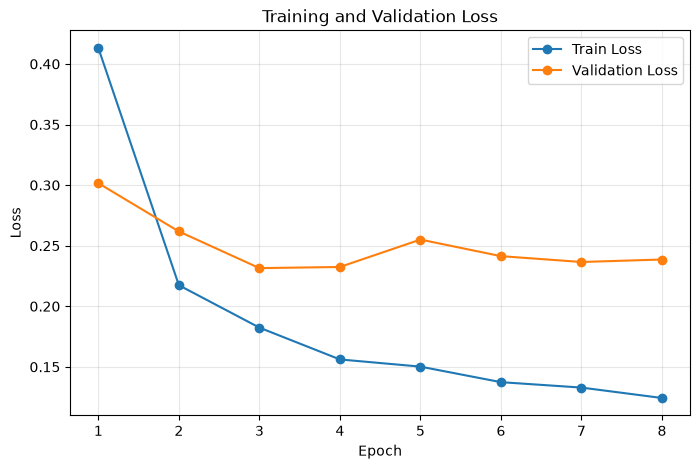

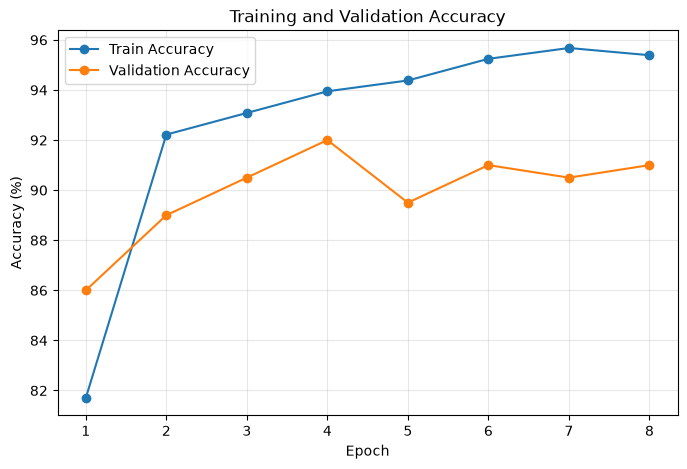

In [46]:
epoch_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epoch_range, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epoch_range, np.array(history["train_acc"]) * 100, marker="o", label="Train Accuracy")
plt.plot(epoch_range, np.array(history["val_acc"]) * 100, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [47]:
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"최고 검증 손실: {checkpoint['best_val_loss']:.4f}")
print("저장된 클래스 정보: ", checkpoint['class_to_idx'])

최고 검증 손실: 0.2315
저장된 클래스 정보:  {'alien': 0, 'predator': 1}


### 단일 이미지 예측 함수

In [48]:
from PIL import Image

In [52]:
def predict_image(image_path, model, transform, device, idx_to_class):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다. {image_path}")

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        logit = model(input_tensor)
        class_1_probabiliy = torch.sigmoid(logit).item()

    probabilities = {
        idx_to_class[0]: 1.0 - class_1_probabiliy,
        idx_to_class[1]: class_1_probabiliy
    }
    predicted_class = max(probabilities, key=probabilities.get)
    return image, predicted_class, probabilities

In [54]:
sample_paths = []
for class_name in class_names:
    class_dir = VAL_DIR / class_name
    candidates = sorted(p for p in class_dir.iterdir() 
                        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"})
    if candidates:
        sample_paths.append(candidates[0])

sample_paths

[WindowsPath('c:/Ryuzy/3_MLDL/data/alien_vs_predator/validation/alien/0.jpg'),
 WindowsPath('c:/Ryuzy/3_MLDL/data/alien_vs_predator/validation/predator/0.jpg')]

In [56]:
plt.rcParams['font.family'] = 'Malgun Gothic'

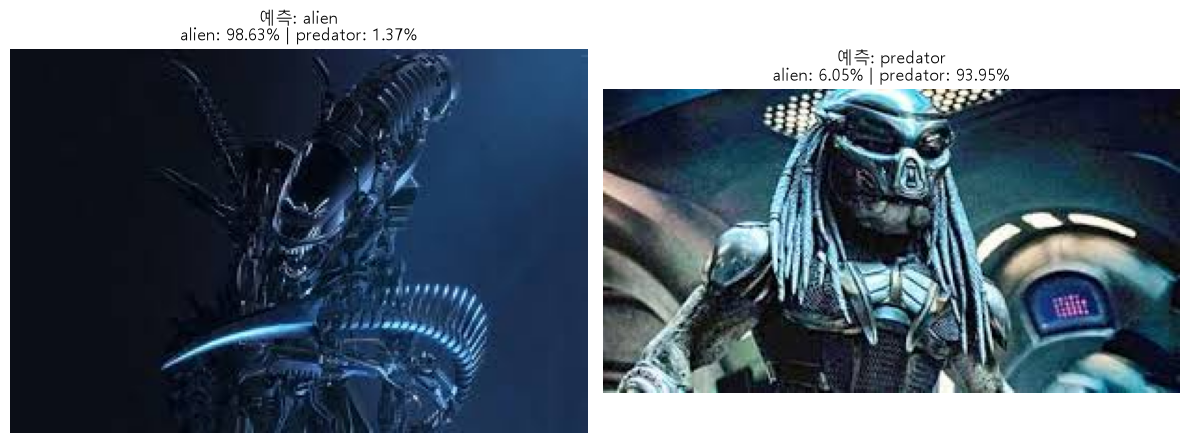

In [57]:
fig, axes = plt.subplots(1, len(sample_paths), figsize=(6 * len(sample_paths), 5))
if len(sample_paths) == 1:
    axes = [axes]

for ax, sample_path in zip(axes, sample_paths):
    image, predicted_class, probabilities = predict_image(
        image_path=sample_path,
        model=model,
        transform=data_transforms["validation"],
        device=device,
        idx_to_class=idx_to_class,
    )

    probability_text = " | ".join(
        f"{name}: {probability * 100:.2f}%"
        for name, probability in probabilities.items()
    )

    ax.imshow(image)
    ax.set_title(f"예측: {predicted_class}\n{probability_text}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [58]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

              precision    recall  f1-score   support

       alien     0.8932    0.9200    0.9064       100
    predator     0.9175    0.8900    0.9036       100

    accuracy                         0.9050       200
   macro avg     0.9054    0.9050    0.9050       200
weighted avg     0.9054    0.9050    0.9050       200



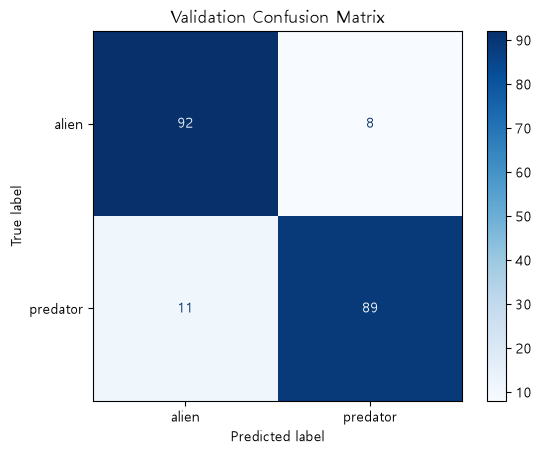

In [59]:
all_labels = []
all_predictions = []

model.eval()
with torch.inference_mode():
    for images, labels in dataloaders["validation"]:
        images = images.to(device, non_blocking=PIN_MEMORY)
        logits = model(images)
        probabilities = torch.sigmoid(logits).squeeze(1)
        predictions = (probabilities >= 0.5).long().cpu()

        all_labels.extend(labels.tolist())
        all_predictions.extend(predictions.tolist())

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_predictions,
    display_labels=class_names,
    cmap="Blues",
)
plt.title("Validation Confusion Matrix")
plt.show()

In [61]:
MY_IMAGE_PATH = DATA_DIR / "ryuzy.jpg"

image, predicted_class, probabilities = predict_image(image_path=MY_IMAGE_PATH,
                                                      model=model,
                                                      transform=data_transforms['validation'],
                                                      device=device,
                                                      idx_to_class=idx_to_class)

In [62]:
for class_name, probability in probabilities.items():
    print(f"{class_name}: {probability * 100:.2f}%")

print(f"결과: 나는 {predicted_class} 쪽에 더 가깝습니다.")

alien: 12.47%
predator: 87.53%
결과: 나는 predator 쪽에 더 가깝습니다.


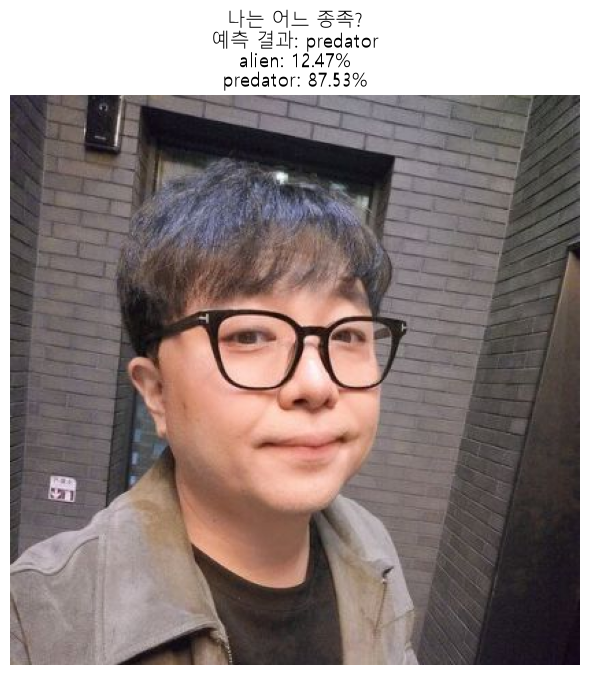

In [63]:
# 사진과 결과 출력
plt.figure(figsize=(6, 7))
plt.imshow(image)
plt.axis("off")

probability_text = "\n".join(
    f"{name}: {probability * 100:.2f}%"
    for name, probability in probabilities.items()
)

plt.title(
    f"나는 어느 종족?\n"
    f"예측 결과: {predicted_class}\n"
    f"{probability_text}",
    fontsize=14
)

plt.tight_layout()
plt.show()